# 🎯 Part 3: 양자화(Quantization) 기법 실습

**학습 목표:**
1. 양자화의 수학적 원리 이해하기 (FP32 → INT8 변환)
2. PTQ (Post-Training Quantization) 실습하기
3. QAT (Quantization-Aware Training) 실습하기

---

In [1]:
# 필요한 라이브러리 설치
!pip install torch torchvision matplotlib numpy -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os

# 시각화 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# GPU 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")
print(f"PyTorch 버전: {torch.__version__}")

사용 디바이스: cpu
PyTorch 버전: 2.9.0+cpu


---
# 🔬 실습 1: 양자화 기초 - FP32에서 INT8로 변환하기

## 1.1 양자화란?

양자화는 **높은 정밀도의 숫자(FP32)를 낮은 정밀도의 숫자(INT8)로 변환**하는 과정입니다.

### 왜 양자화가 필요할까요?
- **메모리 절감**: FP32(4바이트) → INT8(1바이트) = **4배 메모리 절감**
- **속도 향상**: 정수 연산은 부동소수점 연산보다 훨씬 빠름
- **비용 절감**: 더 적은 하드웨어 리소스로 동일한 작업 수행

## 1.2 데이터 타입별 메모리 크기 확인

In [3]:
# 같은 값을 다른 데이터 타입으로 저장했을 때 메모리 차이
print("=" * 50)
print("📊 데이터 타입별 메모리 사용량 비교")
print("=" * 50)

# 100만 개의 파라미터를 가진 텐서 생성
num_params = 1_000_000

tensor_fp32 = torch.randn(num_params, dtype=torch.float32)
tensor_fp16 = tensor_fp32.half()  # FP16
tensor_int8 = tensor_fp32.to(torch.int8)  # INT8

print(f"\n파라미터 수: {num_params:,}개")
print(f"\nFP32 (32-bit): {tensor_fp32.element_size() * tensor_fp32.numel() / 1024 / 1024:.2f} MB")
print(f"FP16 (16-bit): {tensor_fp16.element_size() * tensor_fp16.numel() / 1024 / 1024:.2f} MB")
print(f"INT8 (8-bit):  {tensor_int8.element_size() * tensor_int8.numel() / 1024 / 1024:.2f} MB")

print("\n💡 결론: INT8은 FP32 대비 4배 적은 메모리를 사용합니다!")

📊 데이터 타입별 메모리 사용량 비교

파라미터 수: 1,000,000개

FP32 (32-bit): 3.81 MB
FP16 (16-bit): 1.91 MB
INT8 (8-bit):  0.95 MB

💡 결론: INT8은 FP32 대비 4배 적은 메모리를 사용합니다!


## 1.3 양자화 원리 이해하기 - 지도 축소 비유

### 🗺️ 양자화를 지도 축소에 비유해보면:

**상황**: 서울 전체 지도(1:1 축척)를 손바닥 크기 지도로 만들고 싶다!

```
원본 지도 (FP32)              축소된 지도 (INT8)
┌─────────────────┐           ┌───────┐
│                 │           │       │
│   서울 전체       │  ──────▶  │ 서울  │
│   (정밀함)        │   축소     │(대략) │
│                 │           │       │
└─────────────────┘           └───────┘
    실수 범위                  정수 범위
  -0.5 ~ 0.5                 -128 ~ 127
```

### 핵심 개념 2가지:

**1. Scale (축척 비율)** 🔍
- 원본을 얼마나 줄일지 결정하는 비율
- 예: 1km를 1cm로 표현 → scale = 1/100,000
- 양자화에서: 실수 범위를 정수 범위로 압축하는 비율

**2. Zero Point (기준점)** 📍
- 원본의 '0'이 축소된 지도에서 어디에 위치하는지
- 대칭 양자화: 0은 그대로 0 (zero_point = 0)
- 비대칭 양자화: 0이 다른 값에 매핑될 수 있음

### 양자화 과정을 단계별로:
```
1. 원본 값: 0.15 (FP32)
2. Scale로 나누기: 0.15 / 0.004 = 37.5
3. 반올림: 38 (INT8)
4. 저장! (메모리 4배 절약)

복원할 때 (역양자화):
5. Scale로 곱하기: 38 × 0.004 = 0.152
6. 약간의 오차 발생: 0.15 → 0.152 (오차: 0.002)
```

💡 **핵심 포인트**: 양자화는 '손실 압축'입니다. 완벽히 복원은 안 되지만, 신경망은 이 정도 오차에 놀랍도록 강건합니다!

## 1.4 대칭 양자화 (Symmetric Quantization) 구현

In [4]:
def symmetric_quantize(tensor, num_bits=8):
    """
    대칭 양자화: 0을 중심으로 대칭적으로 매핑
    - zero_point = 0으로 고정
    - 가중치(weights) 양자화에 주로 사용
    """
    # INT8 범위: -128 ~ 127
    qmin = -(2 ** (num_bits - 1))
    qmax = 2 ** (num_bits - 1) - 1

    # Scale 계산: 절대값 최대값 기준
    abs_max = torch.max(torch.abs(tensor))
    scale = abs_max / qmax

    # 양자화
    quantized = torch.round(tensor / scale).clamp(qmin, qmax).to(torch.int8)

    # 역양자화
    dequantized = quantized.float() * scale

    return quantized, dequantized, scale


# 테스트
print("=" * 50)
print("🔄 대칭 양자화 (Symmetric Quantization) 예시")
print("=" * 50)

# 예시 데이터: -0.4 ~ 0.4 범위의 가중치
original = torch.tensor([-0.4, -0.2, 0.0, 0.1, 0.3, 0.4])
quantized, dequantized, scale = symmetric_quantize(original)

print(f"\n원본 (FP32):     {original.tolist()}")
print(f"양자화 (INT8):   {quantized.tolist()}")
print(f"역양자화 (FP32): {[round(x, 4) for x in dequantized.tolist()]}")
print(f"\nScale: {scale:.6f}")
print(f"Zero Point: 0 (대칭 양자화는 항상 0)")

# 오차 계산
error = torch.abs(original - dequantized)
print(f"\n양자화 오차: {error.tolist()}")
print(f"평균 오차: {error.mean():.6f}")

🔄 대칭 양자화 (Symmetric Quantization) 예시

원본 (FP32):     [-0.4000000059604645, -0.20000000298023224, 0.0, 0.10000000149011612, 0.30000001192092896, 0.4000000059604645]
양자화 (INT8):   [-127, -64, 0, 32, 95, 127]
역양자화 (FP32): [-0.4, -0.2016, 0.0, 0.1008, 0.2992, 0.4]

Scale: 0.003150
Zero Point: 0 (대칭 양자화는 항상 0)

양자화 오차: [0.0, 0.0015747994184494019, 0.0, 0.0007873997092247009, 0.0007874071598052979, 0.0]
평균 오차: 0.000525


## 1.5 비대칭 양자화 (Asymmetric Quantization) 구현

In [5]:
def asymmetric_quantize(tensor, num_bits=8):
    """
    비대칭 양자화: 실제 min/max 범위를 그대로 매핑
    - zero_point가 0이 아닐 수 있음
    - 활성화(activations) 양자화에 주로 사용 (ReLU 후 모든 값이 양수)
    """
    # INT8 범위: -128 ~ 127
    qmin = -(2 ** (num_bits - 1))
    qmax = 2 ** (num_bits - 1) - 1

    # 실제 min, max 값
    min_val = tensor.min()
    max_val = tensor.max()

    # Scale 계산
    scale = (max_val - min_val) / (qmax - qmin)

    # Zero Point 계산
    zero_point = qmin - torch.round(min_val / scale)
    zero_point = zero_point.clamp(qmin, qmax).to(torch.int8)

    # 양자화
    quantized = torch.round(tensor / scale + zero_point.float()).clamp(qmin, qmax).to(torch.int8)

    # 역양자화
    dequantized = scale * (quantized.float() - zero_point.float())

    return quantized, dequantized, scale, zero_point


# 테스트: ReLU 후의 활성화 값 (모두 양수)
print("=" * 50)
print("🔄 비대칭 양자화 (Asymmetric Quantization) 예시")
print("=" * 50)

# ReLU 후 활성화 값 예시: 0 ~ 6 범위
activation = torch.tensor([0.0, 0.5, 1.2, 2.8, 4.5, 6.0])
quantized, dequantized, scale, zero_point = asymmetric_quantize(activation)

print(f"\n원본 (FP32):     {activation.tolist()}")
print(f"양자화 (INT8):   {quantized.tolist()}")
print(f"역양자화 (FP32): {[round(x, 4) for x in dequantized.tolist()]}")
print(f"\nScale: {scale:.6f}")
print(f"Zero Point: {zero_point}")

# 오차 계산
error = torch.abs(activation - dequantized)
print(f"\n양자화 오차: {[round(x, 4) for x in error.tolist()]}")
print(f"평균 오차: {error.mean():.6f}")

🔄 비대칭 양자화 (Asymmetric Quantization) 예시

원본 (FP32):     [0.0, 0.5, 1.2000000476837158, 2.799999952316284, 4.5, 6.0]
양자화 (INT8):   [-128, -107, -77, -9, 63, 127]
역양자화 (FP32): [0.0, 0.4941, 1.2, 2.8, 4.4941, 6.0]

Scale: 0.023529
Zero Point: -128

양자화 오차: [0.0, 0.0059, 0.0, 0.0, 0.0059, 0.0]
평균 오차: 0.001961


## 1.6 대칭 vs 비대칭 양자화 시각화

/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-658466279.py:53: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

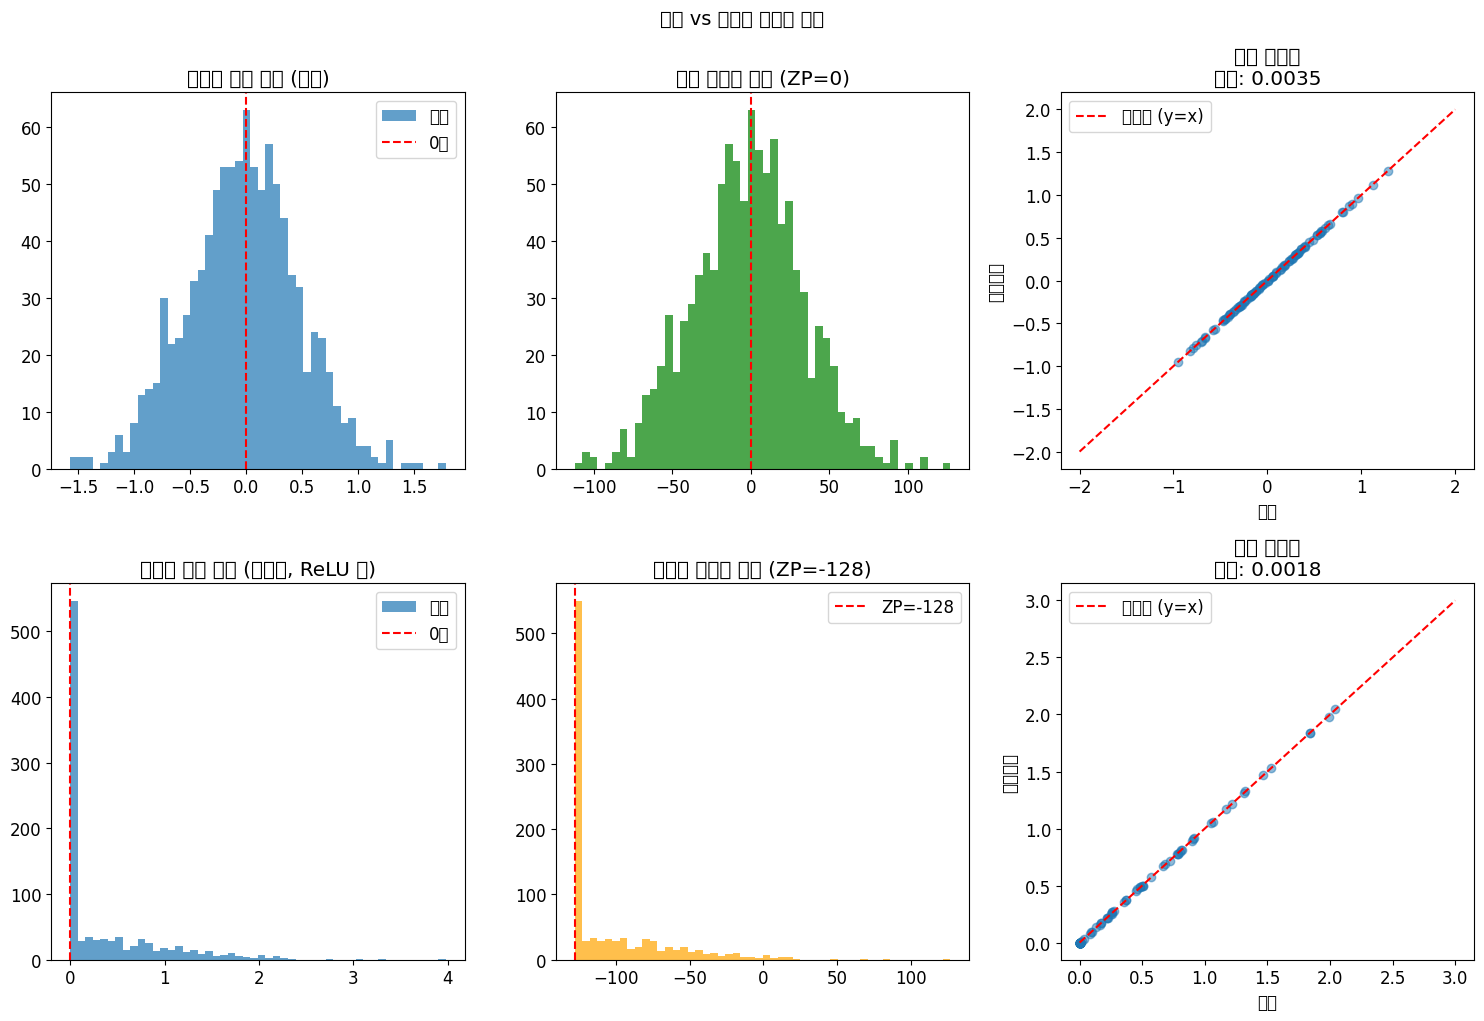


💡 핵심 포인트:
  - 대칭 양자화: 0을 중심으로 분포된 '가중치'에 적합
  - 비대칭 양자화: ReLU 후처럼 한쪽으로 치우친 '활성화'에 적합


In [6]:
# 시각화를 위한 데이터 생성
np.random.seed(42)

# 케이스 1: 대칭 분포 (가중치)
weights = torch.randn(1000) * 0.5  # 0 중심 정규분포

# 케이스 2: 비대칭 분포 (ReLU 후 활성화)
activations = F.relu(torch.randn(1000))  # 0 이상의 값만

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 가중치 - 대칭 양자화
w_quant_sym, w_dequant_sym, w_scale_sym = symmetric_quantize(weights)
w_quant_asym, w_dequant_asym, w_scale_asym, w_zp_asym = asymmetric_quantize(weights)

axes[0, 0].hist(weights.numpy(), bins=50, alpha=0.7, label='원본')
axes[0, 0].axvline(x=0, color='r', linestyle='--', label='0점')
axes[0, 0].set_title('가중치 원본 분포 (대칭)')
axes[0, 0].legend()

axes[0, 1].hist(w_quant_sym.numpy(), bins=50, alpha=0.7, color='green')
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_title('대칭 양자화 결과 (ZP=0)')

axes[0, 2].scatter(weights.numpy()[:100], w_dequant_sym.numpy()[:100], alpha=0.5)
axes[0, 2].plot([-2, 2], [-2, 2], 'r--', label='이상적 (y=x)')
axes[0, 2].set_xlabel('원본')
axes[0, 2].set_ylabel('역양자화')
axes[0, 2].set_title(f'복원 정확도\n오차: {torch.abs(weights - w_dequant_sym).mean():.4f}')
axes[0, 2].legend()

# 활성화 - 비대칭 양자화
a_quant_sym, a_dequant_sym, a_scale_sym = symmetric_quantize(activations)
a_quant_asym, a_dequant_asym, a_scale_asym, a_zp_asym = asymmetric_quantize(activations)

axes[1, 0].hist(activations.numpy(), bins=50, alpha=0.7, label='원본')
axes[1, 0].axvline(x=0, color='r', linestyle='--', label='0점')
axes[1, 0].set_title('활성화 원본 분포 (비대칭, ReLU 후)')
axes[1, 0].legend()

axes[1, 1].hist(a_quant_asym.numpy(), bins=50, alpha=0.7, color='orange')
axes[1, 1].axvline(x=a_zp_asym.item(), color='r', linestyle='--', label=f'ZP={a_zp_asym.item()}')
axes[1, 1].set_title(f'비대칭 양자화 결과 (ZP={a_zp_asym.item()})')
axes[1, 1].legend()

axes[1, 2].scatter(activations.numpy()[:100], a_dequant_asym.numpy()[:100], alpha=0.5)
axes[1, 2].plot([0, 3], [0, 3], 'r--', label='이상적 (y=x)')
axes[1, 2].set_xlabel('원본')
axes[1, 2].set_ylabel('역양자화')
axes[1, 2].set_title(f'복원 정확도\n오차: {torch.abs(activations - a_dequant_asym).mean():.4f}')
axes[1, 2].legend()

plt.tight_layout()
plt.suptitle('대칭 vs 비대칭 양자화 비교', fontsize=14, y=1.02)
plt.show()

print("\n💡 핵심 포인트:")
print("  - 대칭 양자화: 0을 중심으로 분포된 '가중치'에 적합")
print("  - 비대칭 양자화: ReLU 후처럼 한쪽으로 치우친 '활성화'에 적합")

## 1.7 양자화 세분성(Granularity) 이해하기

In [7]:
# Per-Tensor vs Per-Channel 양자화 비교
print("=" * 60)
print("📊 양자화 세분성(Granularity) 비교")
print("=" * 60)

# 가상의 Conv 레이어 가중치 생성 (4개 출력 채널)
# 각 채널마다 다른 범위의 값을 가짐
weight = torch.zeros(4, 3, 3, 3)  # (out_ch, in_ch, H, W)
weight[0] = torch.randn(3, 3, 3) * 0.1   # 채널 0: 작은 범위
weight[1] = torch.randn(3, 3, 3) * 0.5   # 채널 1: 중간 범위
weight[2] = torch.randn(3, 3, 3) * 1.0   # 채널 2: 큰 범위
weight[3] = torch.randn(3, 3, 3) * 2.0   # 채널 3: 매우 큰 범위

print("\n각 출력 채널의 가중치 범위:")
for i in range(4):
    print(f"  채널 {i}: [{weight[i].min():.3f}, {weight[i].max():.3f}]")

# Per-Tensor 양자화: 전체 텐서에 하나의 scale
def per_tensor_quantize(tensor):
    abs_max = torch.max(torch.abs(tensor))
    scale = abs_max / 127
    quantized = torch.round(tensor / scale).clamp(-128, 127).to(torch.int8)
    dequantized = quantized.float() * scale
    return dequantized, scale

# Per-Channel 양자화: 각 출력 채널마다 다른 scale
def per_channel_quantize(tensor):
    scales = []
    dequantized = torch.zeros_like(tensor)
    for i in range(tensor.shape[0]):
        abs_max = torch.max(torch.abs(tensor[i]))
        scale = abs_max / 127
        scales.append(scale.item())
        quantized_ch = torch.round(tensor[i] / scale).clamp(-128, 127).to(torch.int8)
        dequantized[i] = quantized_ch.float() * scale
    return dequantized, scales

# 양자화 수행
dequant_tensor, scale_tensor = per_tensor_quantize(weight)
dequant_channel, scales_channel = per_channel_quantize(weight)

# 오차 비교
print("\n" + "=" * 60)
print("Per-Tensor vs Per-Channel 양자화 오차 비교")
print("=" * 60)

print(f"\n📌 Per-Tensor 양자화:")
print(f"   - 단일 Scale: {scale_tensor:.6f}")
for i in range(4):
    error = torch.abs(weight[i] - dequant_tensor[i]).mean()
    print(f"   - 채널 {i} 평균 오차: {error:.6f}")
print(f"   - 전체 평균 오차: {torch.abs(weight - dequant_tensor).mean():.6f}")

print(f"\n📌 Per-Channel 양자화:")
print(f"   - 채널별 Scale: {[f'{s:.6f}' for s in scales_channel]}")
for i in range(4):
    error = torch.abs(weight[i] - dequant_channel[i]).mean()
    print(f"   - 채널 {i} 평균 오차: {error:.6f}")
print(f"   - 전체 평균 오차: {torch.abs(weight - dequant_channel).mean():.6f}")

print("\n💡 결론: Per-Channel이 더 정확하지만 메타데이터(scale) 저장 공간이 더 필요합니다.")

📊 양자화 세분성(Granularity) 비교

각 출력 채널의 가중치 범위:
  채널 0: [-0.196, 0.230]
  채널 1: [-0.588, 0.887]
  채널 2: [-2.060, 2.391]
  채널 3: [-2.597, 2.953]

Per-Tensor vs Per-Channel 양자화 오차 비교

📌 Per-Tensor 양자화:
   - 단일 Scale: 0.023254
   - 채널 0 평균 오차: 0.005889
   - 채널 1 평균 오차: 0.006875
   - 채널 2 평균 오차: 0.005513
   - 채널 3 평균 오차: 0.006030
   - 전체 평균 오차: 0.006077

📌 Per-Channel 양자화:
   - 채널별 Scale: ['0.001811', '0.006982', '0.018829', '0.023254']
   - 채널 0 평균 오차: 0.000444
   - 채널 1 평균 오차: 0.002054
   - 채널 2 평균 오차: 0.004552
   - 채널 3 평균 오차: 0.006030
   - 전체 평균 오차: 0.003270

💡 결론: Per-Channel이 더 정확하지만 메타데이터(scale) 저장 공간이 더 필요합니다.


---
# 🔬 실습 2: PTQ (Post-Training Quantization)

## 2.1 PTQ란?

**Post-Training Quantization (훈련 후 양자화)**는 이미 훈련된 모델을 양자화하는 방법입니다.

### 장점:
- ✅ 재훈련 불필요 → 빠른 적용
- ✅ 원본 학습 데이터 불필요 (보정용 소량 데이터만 필요)

### 단점:
- ⚠️ 양자화 오차를 보정할 기회가 없음
- ⚠️ 극단적 양자화(INT4)에서 성능 저하 가능

## 2.2 실습용 모델 및 데이터 준비

In [8]:
# 간단한 CNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# MNIST 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 보정(calibration)용 데이터 로더 (PTQ에서 사용)
calibration_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

print(f"학습 데이터: {len(train_dataset)}개")
print(f"테스트 데이터: {len(test_dataset)}개")

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

학습 데이터: 60000개
테스트 데이터: 10000개


## 2.3 모델 훈련 (FP32)

In [9]:
def train_model(model, train_loader, epochs=3):
    """모델 훈련 함수"""
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        accuracy = 100. * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return model


def evaluate_model(model, test_loader):
    """모델 평가 함수"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    accuracy = 100. * correct / total
    return accuracy


# FP32 모델 훈련
print("=" * 50)
print("🚀 FP32 모델 훈련 시작")
print("=" * 50)

model_fp32 = SimpleCNN()
model_fp32 = train_model(model_fp32, train_loader, epochs=3)

# 평가
accuracy_fp32 = evaluate_model(model_fp32, test_loader)
print(f"\n✅ FP32 모델 정확도: {accuracy_fp32:.2f}%")

🚀 FP32 모델 훈련 시작
Epoch 1/3 - Loss: 0.1619, Accuracy: 95.12%
Epoch 2/3 - Loss: 0.0679, Accuracy: 97.95%
Epoch 3/3 - Loss: 0.0525, Accuracy: 98.42%

✅ FP32 모델 정확도: 99.06%


## 2.4 Dynamic Quantization (동적 양자화)

가장 간단한 PTQ 방법입니다. **가중치만 사전에 양자화**하고, 활성화는 런타임에 동적으로 양자화합니다.

In [10]:
# Dynamic Quantization 적용
print("=" * 50)
print("🔄 Dynamic Quantization 적용")
print("=" * 50)

# 모델 복사 (원본 유지)
model_dynamic = SimpleCNN()
model_dynamic.load_state_dict(model_fp32.state_dict())

# Dynamic Quantization 적용 (Linear 레이어만)
model_dynamic_quantized = torch.quantization.quantize_dynamic(
    model_dynamic,
    {nn.Linear},  # 양자화할 레이어 타입
    dtype=torch.qint8
)

print("\n양자화된 모델 구조:")
print(model_dynamic_quantized)

# 평가
accuracy_dynamic = evaluate_model(model_dynamic_quantized, test_loader)
print(f"\n✅ Dynamic Quantized 모델 정확도: {accuracy_dynamic:.2f}%")
print(f"📉 정확도 변화: {accuracy_dynamic - accuracy_fp32:+.2f}%")

🔄 Dynamic Quantization 적용

양자화된 모델 구조:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): DynamicQuantizedLinear(in_features=3136, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc2): DynamicQuantizedLinear(in_features=128, out_features=10, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (dropout): Dropout(p=0.25, inplace=False)
)


/tmp/ipython-input-1286825785.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_dynamic_quantized = torch.quantization.quantize_dynamic(



✅ Dynamic Quantized 모델 정확도: 99.05%
📉 정확도 변화: -0.01%


## 2.5 Static Quantization (정적 양자화)

**가중치와 활성화 모두 사전에 양자화**합니다. 보정(calibration) 데이터가 필요합니다.

In [13]:
# Static Quantization을 위한 모델 재정의 (QuantStub, DeQuantStub 추가)
class SimpleCNN_Quantizable(nn.Module):
    def __init__(self):
        super(SimpleCNN_Quantizable, self).__init__()
        # 양자화/역양자화 시작/끝 지점 표시
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.quant(x)  # 입력 양자화
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.reshape(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.dequant(x)  # 출력 역양자화
        return x

    def fuse_model(self):
        """Conv-BN-ReLU 융합 (최적화)"""
        torch.quantization.fuse_modules(
            self,
            [['conv1', 'bn1'], ['conv2', 'bn2']],
            inplace=True
        )


print("=" * 50)
print("🔄 Static Quantization 적용")
print("=" * 50)

# 1. 모델 생성 및 가중치 로드
model_static = SimpleCNN_Quantizable()

# 기존 FP32 모델의 가중치를 새 모델에 로드 (키 매칭 필요)
state_dict = model_fp32.state_dict()
# dropout 레이어 관련 키 제거 (새 모델에는 없음)
state_dict = {k: v for k, v in state_dict.items() if 'dropout' not in k}
model_static.load_state_dict(state_dict, strict=False)

model_static.eval()

# 2. Conv-BN 융합
model_static.fuse_model()
print("✅ Conv-BN 레이어 융합 완료")

# 3. 양자화 설정
model_static.qconfig = torch.quantization.get_default_qconfig('fbgemm')  # x86 CPU용
print(f"✅ QConfig 설정: {model_static.qconfig}")

# 4. 양자화 준비
torch.quantization.prepare(model_static, inplace=True)
print("✅ 양자화 준비 완료 (Observer 삽입)")

# 5. 보정 (Calibration) - 대표 데이터로 통계 수집
print("\n🔍 보정(Calibration) 진행 중...")
with torch.no_grad():
    for i, (data, _) in enumerate(calibration_loader):
        model_static(data)
        if i >= 10:  # 약 1000개 샘플
            break
print("✅ 보정 완료")

# 6. 양자화 변환
torch.quantization.convert(model_static, inplace=True)
print("✅ 양자화 변환 완료")

# 평가
accuracy_static = evaluate_model(model_static, test_loader)
print(f"\n✅ Static Quantized 모델 정확도: {accuracy_static:.2f}%")
print(f"📉 정확도 변화: {accuracy_static - accuracy_fp32:+.2f}%")

🔄 Static Quantization 적용
✅ Conv-BN 레이어 융합 완료
✅ QConfig 설정: QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.PerChannelMinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_channel_symmetric){})
✅ 양자화 준비 완료 (Observer 삽입)

🔍 보정(Calibration) 진행 중...


/tmp/ipython-input-4120908650.py:60: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quantization.prepare(model_static, inplace=True)


✅ 보정 완료
✅ 양자화 변환 완료


/tmp/ipython-input-4120908650.py:73: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quantization.convert(model_static, inplace=True)



✅ Static Quantized 모델 정확도: 99.05%
📉 정확도 변화: -0.01%


## 2.6 모델 크기 및 추론 속도 비교

📊 양자화 전후 비교

------------------------------------------------------------
모델                        크기(MB)       속도(ms)       정확도(%)    
------------------------------------------------------------
FP32 (원본)                 1.62         837.29       99.06     
Dynamic Quantized         0.47         828.15       99.05     
Static Quantized          0.41         291.10       99.05     
------------------------------------------------------------


/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1550810290.py:79: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

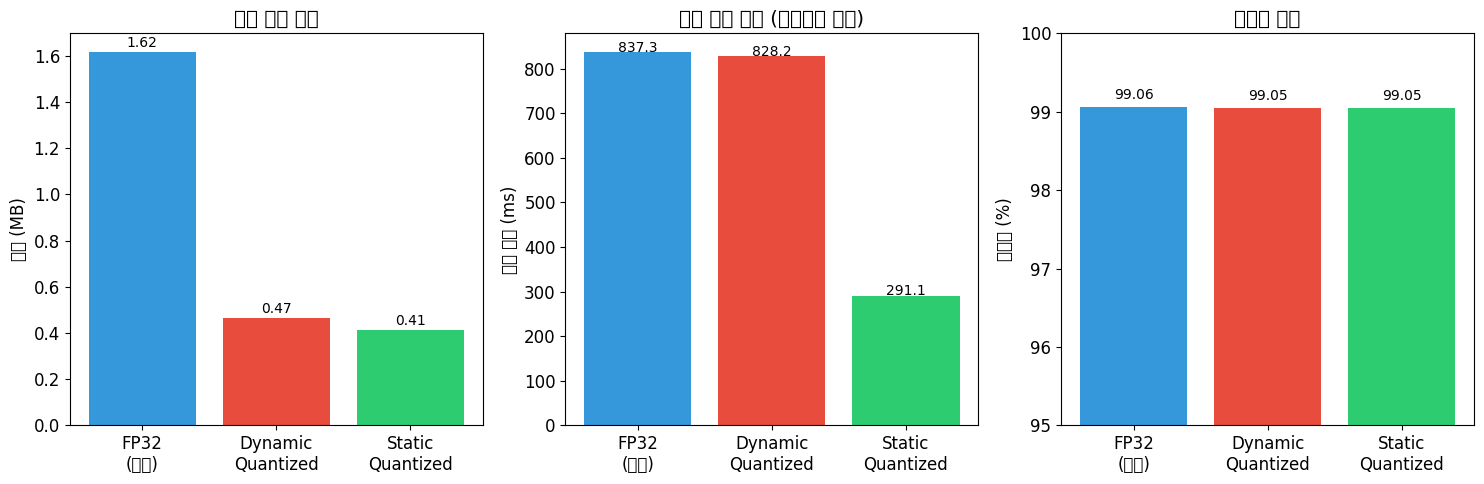


💡 결론:
  - 크기 감소: 74.4% (Static Quantization)
  - 정확도 손실: 0.01% 이하


In [14]:
def get_model_size(model, temp_file='temp_model.pt'):
    """모델 크기 측정 (MB)"""
    torch.save(model.state_dict(), temp_file)
    size_mb = os.path.getsize(temp_file) / (1024 * 1024)
    os.remove(temp_file)
    return size_mb


def measure_inference_time(model, test_loader, num_batches=10):
    """추론 시간 측정"""
    model.eval()
    times = []

    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            if i >= num_batches:
                break
            start = time.time()
            _ = model(data)
            times.append(time.time() - start)

    return np.mean(times) * 1000  # ms


print("=" * 60)
print("📊 양자화 전후 비교")
print("=" * 60)

# 모델 크기 비교
size_fp32 = get_model_size(model_fp32)
size_dynamic = get_model_size(model_dynamic_quantized)
size_static = get_model_size(model_static)

# 추론 속도 비교
time_fp32 = measure_inference_time(model_fp32, test_loader)
time_dynamic = measure_inference_time(model_dynamic_quantized, test_loader)
time_static = measure_inference_time(model_static, test_loader)

# 결과 출력
print("\n" + "-" * 60)
print(f"{'모델':<25} {'크기(MB)':<12} {'속도(ms)':<12} {'정확도(%)':<10}")
print("-" * 60)
print(f"{'FP32 (원본)':<25} {size_fp32:<12.2f} {time_fp32:<12.2f} {accuracy_fp32:<10.2f}")
print(f"{'Dynamic Quantized':<25} {size_dynamic:<12.2f} {time_dynamic:<12.2f} {accuracy_dynamic:<10.2f}")
print(f"{'Static Quantized':<25} {size_static:<12.2f} {time_static:<12.2f} {accuracy_static:<10.2f}")
print("-" * 60)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['FP32\n(원본)', 'Dynamic\nQuantized', 'Static\nQuantized']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# 모델 크기
sizes = [size_fp32, size_dynamic, size_static]
axes[0].bar(models, sizes, color=colors)
axes[0].set_ylabel('크기 (MB)')
axes[0].set_title('모델 크기 비교')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

# 추론 속도
times = [time_fp32, time_dynamic, time_static]
axes[1].bar(models, times, color=colors)
axes[1].set_ylabel('추론 시간 (ms)')
axes[1].set_title('추론 속도 비교 (낮을수록 빠름)')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

# 정확도
accs = [accuracy_fp32, accuracy_dynamic, accuracy_static]
axes[2].bar(models, accs, color=colors)
axes[2].set_ylabel('정확도 (%)')
axes[2].set_title('정확도 비교')
axes[2].set_ylim([95, 100])
for i, v in enumerate(accs):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 결론:")
print(f"  - 크기 감소: {(1 - size_static/size_fp32)*100:.1f}% (Static Quantization)")
print(f"  - 정확도 손실: {accuracy_fp32 - accuracy_static:.2f}% 이하")

---
# 🔬 실습 3: QAT (Quantization-Aware Training)

## 3.1 QAT란?

**Quantization-Aware Training (양자화 인식 훈련)**은 훈련 과정에서 양자화로 인한 오차를 미리 시뮬레이션하여 학습에 반영하는 기법입니다.

### 핵심 개념: Fake Quantization
- 훈련 중에는 실제로 INT8로 변환하지 않음
- 대신 "양자화 → 역양자화" 과정을 시뮬레이션하여 오차를 학습에 반영
- Forward: Fake Quantize 적용
- Backward: Straight-Through Estimator (STE) 사용

### 장점:
- ✅ PTQ보다 높은 정확도 유지
- ✅ 극단적 양자화(INT4)에서도 우수한 성능

### 단점:
- ⚠️ 전체 학습 파이프라인과 데이터셋 필요
- ⚠️ 학습 시간 증가

## 3.2 Fake Quantization 이해하기

In [15]:
# Fake Quantization 시뮬레이션
def fake_quantize(tensor, num_bits=8):
    """
    Fake Quantization: 실제로는 FP32를 유지하지만,
    양자화-역양자화 과정에서 발생하는 오차를 시뮬레이션
    """
    qmin = -(2 ** (num_bits - 1))
    qmax = 2 ** (num_bits - 1) - 1

    # Scale 계산
    abs_max = torch.max(torch.abs(tensor))
    scale = abs_max / qmax

    # 양자화 시뮬레이션 (실제로는 INT8로 변환하지 않음)
    quantized = torch.round(tensor / scale).clamp(qmin, qmax)

    # 역양자화 → FP32로 복원 (하지만 양자화 오차는 포함됨)
    fake_quantized = quantized * scale

    return fake_quantized


print("=" * 50)
print("🔄 Fake Quantization 시뮬레이션")
print("=" * 50)

# 예시 가중치
original = torch.tensor([0.123, -0.456, 0.789, -0.012, 0.345])
fake_quant = fake_quantize(original)

print(f"\n원본 (FP32):        {original.tolist()}")
print(f"Fake Quantized:     {[round(x, 4) for x in fake_quant.tolist()]}")
print(f"\n오차:               {[round(x, 6) for x in (original - fake_quant).tolist()]}")

print("\n💡 핵심:")
print("  - 실제 데이터 타입은 여전히 FP32 (훈련 가능)")
print("  - 하지만 값은 INT8 양자화를 거친 것처럼 변형됨")
print("  - 이를 통해 모델이 양자화 오차에 적응하도록 학습")

🔄 Fake Quantization 시뮬레이션

원본 (FP32):        [0.12300000339746475, -0.4560000002384186, 0.7889999747276306, -0.012000000104308128, 0.3449999988079071]
Fake Quantized:     [0.1243, -0.4535, 0.789, -0.0124, 0.3479]

오차:               [-0.001252, -0.00248, 0.0, 0.000425, -0.002905]

💡 핵심:
  - 실제 데이터 타입은 여전히 FP32 (훈련 가능)
  - 하지만 값은 INT8 양자화를 거친 것처럼 변형됨
  - 이를 통해 모델이 양자화 오차에 적응하도록 학습


## 3.3 QAT 모델 구현

In [ ]:
# QAT용 모델 정의
class SimpleCNN_QAT(nn.Module):
    def __init__(self):
        super(SimpleCNN_QAT, self).__init__()
        self.quant = torch.quantization.QuantStub()
        self.dequant = torch.quantization.DeQuantStub()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()

        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.quant(x)
        x = self.pool(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool(self.relu2(self.bn2(self.conv2(x))))
        x = x.reshape(-1, 64 * 7 * 7)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        x = self.dequant(x)
        return x

    def fuse_model(self):
        torch.quantization.fuse_modules(
            self,
            [['conv1', 'bn1', 'relu1'], ['conv2', 'bn2', 'relu2']],
            inplace=True
        )


print("=" * 50)
print("🚀 QAT (Quantization-Aware Training) 시작")
print("=" * 50)

🚀 QAT (Quantization-Aware Training) 시작


## 3.4 QAT 훈련 실행

In [31]:
def train_qat_model(model, train_loader, epochs=3):
    """QAT 모델 훈련"""
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

        accuracy = 100. * correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

    return model

# 1. 모델 생성
model_qat = SimpleCNN_QAT()

# ✅ 2. 레이어 융합은 eval에서 해야 함
model_qat.eval()
model_qat.fuse_model()
print("✅ Conv-BN-ReLU 레이어 융합 완료")

# ✅ 3. QAT는 다시 train 모드에서 진행
model_qat.train()

# 4. QAT 설정
model_qat.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')
print("✅ QAT QConfig 설정 완료")

# 5. QAT 준비
torch.quantization.prepare_qat(model_qat, inplace=True)
print("✅ QAT 준비 완료 (Fake Quantize 노드 삽입)")

# 6. QAT 훈련
model_qat = train_qat_model(model_qat, train_loader, epochs=3)

# 7. 변환
model_qat.eval()
model_qat_quantized = torch.quantization.convert(model_qat)
print("\n✅ QAT 훈련 완료 및 INT8 변환 완료")

# 8 QAT 정확도 계산
accuracy_qat = evaluate_model(model_qat_quantized, test_loader)
print(f"✅ QAT Quantized 모델 정확도: {accuracy_qat:.2f}%")

✅ Conv-BN-ReLU 레이어 융합 완료
✅ QAT QConfig 설정 완료
✅ QAT 준비 완료 (Fake Quantize 노드 삽입)


/tmp/ipython-input-3937560932.py:46: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quantization.prepare_qat(model_qat, inplace=True)


Epoch 1/3 - Loss: 0.2118, Accuracy: 96.00%
Epoch 2/3 - Loss: 0.0407, Accuracy: 98.71%
Epoch 3/3 - Loss: 0.0271, Accuracy: 99.12%

✅ QAT 훈련 완료 및 INT8 변환 완료


/tmp/ipython-input-3937560932.py:54: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_qat_quantized = torch.quantization.convert(model_qat)


✅ QAT Quantized 모델 정확도: 98.83%


## 3.5 PTQ vs QAT 최종 비교

📊 최종 비교: FP32 vs PTQ vs QAT

모델                        크기(MB)       속도(ms)       정확도(%)       특징
----------------------------------------------------------------------
FP32 (원본)                 1.62         837.29       99.06        기준
PTQ - Dynamic             0.47         828.15       99.05        가장 빠른 적용
PTQ - Static              0.41         291.10       99.05        보정 필요
QAT                       0.41         302.64       98.83        재훈련 필요
----------------------------------------------------------------------


/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2994686098.py:47: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

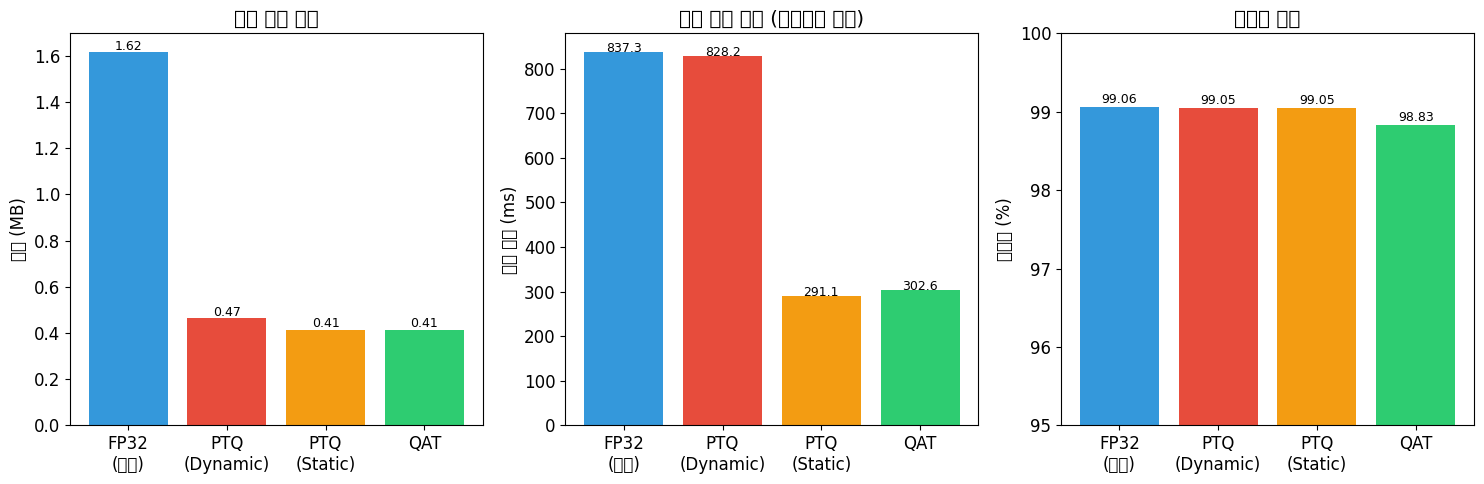

In [32]:
# 모델 크기 측정
size_qat = get_model_size(model_qat_quantized)
time_qat = measure_inference_time(model_qat_quantized, test_loader)

print("=" * 70)
print("📊 최종 비교: FP32 vs PTQ vs QAT")
print("=" * 70)
print(f"\n{'모델':<25} {'크기(MB)':<12} {'속도(ms)':<12} {'정확도(%)':<12} {'특징'}")
print("-" * 70)
print(f"{'FP32 (원본)':<25} {size_fp32:<12.2f} {time_fp32:<12.2f} {accuracy_fp32:<12.2f} 기준")
print(f"{'PTQ - Dynamic':<25} {size_dynamic:<12.2f} {time_dynamic:<12.2f} {accuracy_dynamic:<12.2f} 가장 빠른 적용")
print(f"{'PTQ - Static':<25} {size_static:<12.2f} {time_static:<12.2f} {accuracy_static:<12.2f} 보정 필요")
print(f"{'QAT':<25} {size_qat:<12.2f} {time_qat:<12.2f} {accuracy_qat:<12.2f} 재훈련 필요")
print("-" * 70)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['FP32\n(원본)', 'PTQ\n(Dynamic)', 'PTQ\n(Static)', 'QAT']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

# 모델 크기
sizes = [size_fp32, size_dynamic, size_static, size_qat]
axes[0].bar(models, sizes, color=colors)
axes[0].set_ylabel('크기 (MB)')
axes[0].set_title('모델 크기 비교')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# 추론 속도
times = [time_fp32, time_dynamic, time_static, time_qat]
axes[1].bar(models, times, color=colors)
axes[1].set_ylabel('추론 시간 (ms)')
axes[1].set_title('추론 속도 비교 (낮을수록 빠름)')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

# 정확도
accs = [accuracy_fp32, accuracy_dynamic, accuracy_static, accuracy_qat]
axes[2].bar(models, accs, color=colors)
axes[2].set_ylabel('정확도 (%)')
axes[2].set_title('정확도 비교')
axes[2].set_ylim([95, 100])
for i, v in enumerate(accs):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3.6 PTQ vs QAT 선택 가이드

In [33]:
print("""
╔════════════════════════════════════════════════════════════════════════╗
║                    🎯 PTQ vs QAT 선택 가이드                            ║
╠════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  📌 PTQ (Post-Training Quantization)를 선택할 때:                       ║
║     ✓ 빠른 배포가 필요한 경우                                          ║
║     ✓ 학습 데이터나 리소스가 부족한 경우                                ║
║     ✓ INT8 정도의 양자화로 충분한 경우                                  ║
║     ✓ 빠른 프로토타이핑이 목표인 경우                                   ║
║                                                                        ║
║  📌 QAT (Quantization-Aware Training)를 선택할 때:                      ║
║     ✓ 최고 성능이 필요한 경우                                          ║
║     ✓ 극단적 양자화(INT4, INT2)가 필요한 경우                           ║
║     ✓ 학습 리소스와 시간이 충분한 경우                                  ║
║     ✓ 프로덕션 환경에서 최적화가 중요한 경우                            ║
║                                                                        ║
║  💡 실무 팁:                                                           ║
║     1. PTQ로 빠르게 프로토타입 검증                                     ║
║     2. 성능이 부족하면 QAT로 재훈련                                     ║
║     3. 하이브리드 접근: PTQ → QAT 순차 적용                             ║
║                                                                        ║
╚════════════════════════════════════════════════════════════════════════╝
""")


╔════════════════════════════════════════════════════════════════════════╗
║                    🎯 PTQ vs QAT 선택 가이드                            ║
╠════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  📌 PTQ (Post-Training Quantization)를 선택할 때:                       ║
║     ✓ 빠른 배포가 필요한 경우                                          ║
║     ✓ 학습 데이터나 리소스가 부족한 경우                                ║
║     ✓ INT8 정도의 양자화로 충분한 경우                                  ║
║     ✓ 빠른 프로토타이핑이 목표인 경우                                   ║
║                                                                        ║
║  📌 QAT (Quantization-Aware Training)를 선택할 때:                      ║
║     ✓ 최고 성능이 필요한 경우                                          ║
║     ✓ 극단적 양자화(INT4, INT2)가 필요한 경우                           ║
║     ✓ 학습 리소스와 시간이 충분한 경우                                  ║
║     ✓ 프로덕션 환경에서 최적화가 중요한 경우                 

---
# 📝 실습 정리

## 오늘 배운 내용

### 1️⃣ 양자화 기초
- **양자화**: FP32 → INT8 변환으로 모델 크기 4배 감소
- **대칭 양자화**: 가중치(weights)에 적합, zero_point=0
- **비대칭 양자화**: 활성화(activations)에 적합, 전체 범위 활용
- **세분성**: Per-Tensor < Per-Channel < Per-Group (정확도 증가)

### 2️⃣ PTQ (Post-Training Quantization)
- **Dynamic Quantization**: 가장 간단, 가중치만 사전 양자화
- **Static Quantization**: 가중치+활성화 모두 양자화, 보정 필요
- **장점**: 빠른 적용, 재훈련 불필요
- **단점**: 극단적 양자화에서 성능 저하 가능

### 3️⃣ QAT (Quantization-Aware Training)
- **Fake Quantization**: 훈련 중 양자화 오차 시뮬레이션
- **장점**: 높은 정확도 유지, 극단적 양자화에서도 우수
- **단점**: 재훈련 필요, 시간과 리소스 소요

## 🚀 다음 단계
- Part 4에서 실제 LLM에 양자화 적용하기 (GPTQ, AWQ, bitsandbytes)
- TensorRT, ONNX Runtime을 활용한 실전 배포